In [142]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import Optional
import numpy as np
from tqdm.notebook import tqdm, trange
from src.models_paper import MG_Daily, HMG_Intraday, CNN_Daily, LSTM_Daily
from src.data import MarketDataset
from torch.utils.data import TensorDataset, DataLoader
from src.utils import get_nasdaq_tickers, debug_pass, _init_weights, get_sp500_tickers, print_num_params, get_nasdaq_100_tickers
from src.trainer import BinaryTrainer
import yfinance as yf
import os
from pathlib import Path
from datetime import datetime
import pandas as pd
import random

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Présentation du Dataset S&P500 utilisé

Les auteurs de "Hierarchical Multi-Scale Gaussian Transformer for Stock Movement Prediction" utilisent les actions du NASDAQ, beaucoup plus nombreuses (environ 3000 actions).
Ici par manque de ressources, nous n'utiliserons que les actions du S&P500 afin d'essayer de reproduire les résultats du papier pour les données journalières.
Nous n'implémenterons pas les modèles sur données intraday étant donnée que ces données ne sont pas disponibles gratuitement.

In [157]:
tickers = get_sp500_tickers()
N = 5
data = MarketDataset(tickers=tickers, start='2010-07-01', end='2019-07-01', window_N=N)

print(f"Nombre d'actifs : {len(data.raw.groupby(level=0))}")
print(f"Start date: {data.start}, end date: {data.end}")
print(f"Fréquence des données : 1 jour")
print(f"Nombre total d'observations : {len(data.raw)}")
print(f"Seuil de hausse : {data.beta_rise}")
print(f"Seuil de baisse : {data.beta_fall}")




15 Failed downloads:
['VLTO', 'ABNB', 'SW', 'GEV', 'DASH', 'EXE', 'SOLV', 'OTIS', 'CEG', 'KVUE', 'GEHC', 'CARR', 'PLTR']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-07-01 -> 2019-07-01) (Yahoo error = "Data doesn\'t exist for startDate = 1277956800, endDate = 1561953600")')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-07-01 -> 2019-07-01)')
['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


[!] 15 ticker(s) sans données : ABNB, BF.B, BRK.B, CARR, CEG, DASH, EXE, GEHC, GEV, KVUE, OTIS, PLTR, SOLV, SW, VLTO


/Users/alexandre/ml_for_finance/src/data.py:79: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  if df.empty:


Nombre d'actifs : 488
Start date: 2010-07-01, end date: 2019-07-01
Fréquence des données : 1 jour
Nombre total d'observations : 1050114
Seuil de hausse : 0.0055
Seuil de baisse : -0.001


# Modèles CNN

### CNN sur données journalières du S&P500 de 2010 à 2019

- N = 5
- kernel_size = 3
- n_filters = 32

In [47]:
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
print("\n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")



Nombre de stocks retenus: 488
Shape train: torch.Size([648636, 5, 5])
Shape val: torch.Size([81030, 5, 5])
Shape test: torch.Size([80806, 5, 5])


In [48]:
mg_daily = CNN_Daily(N, F)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

Total parameters: 6,977
Trainable parameters: 6,977


In [49]:
trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = "CNN_Daily_SP500_N5")

trainer.fit()

trainer.evaluate(Xtest, ytest)


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6977,0.6050,0.6451,0.8533,0.7347,0.0199,0.8533,0.8384,0.1616,0.1467
test,0.7285,0.5244,0.5614,0.5275,0.5440,0.0481,0.5275,0.4793,0.5207,0.4725


### CNN sur données journalières du S&P500 de 2010 à 2019

- N = 10
- kernel_size = 3
- n_filters = 32

In [50]:
N = 10
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = CNN_Daily(N, F)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"CNN_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 6,977
Trainable parameters: 6,977
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([646968, 10, 5])
Shape val: torch.Size([81043, 10, 5])
Shape test: torch.Size([80468, 10, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6945,0.6071,0.6507,0.8324,0.7304,0.0502,0.8324,0.7921,0.2079,0.1676
test,0.7321,0.5256,0.6000,0.4744,0.5299,0.0659,0.4744,0.4084,0.5916,0.5256


### CNN sur données journalières du S&P500 de 2010 à 2019

- N = 20
- kernel_size = 3
- n_filters = 32

In [51]:
N = 20
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = CNN_Daily(N, F)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"CNN_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


[!] Skipping CRWD: not enough data (12 rows)
Total parameters: 6,977
Trainable parameters: 6,977
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([643512, 20, 5])
Shape val: torch.Size([80426, 20, 5])
Shape test: torch.Size([80412, 20, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6935,0.6108,0.7990,0.6770,0.7329,0.0352,0.6770,0.6364,0.3636,0.3230
test,0.7253,0.5309,0.4640,0.4328,0.4478,0.0411,0.4328,0.3921,0.6079,0.5672


### CNN sur données journalières du S&P500 de 2010 à 2019

- N = 40
- kernel_size = 3
- n_filters = 32

In [52]:
N = 40
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = CNN_Daily(N, F)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"CNN_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


[!] Skipping CRWD: not enough data (12 rows)
[!] Skipping CTVA: not enough data (24 rows)
[!] Skipping UBER: not enough data (34 rows)
Total parameters: 6,977
Trainable parameters: 6,977
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([637241, 40, 5])
Shape val: torch.Size([79798, 40, 5])
Shape test: torch.Size([79333, 40, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6927,0.6148,0.6842,0.7889,0.7328,0.0571,0.7889,0.7380,0.2620,0.2111
test,0.7265,0.5287,0.5383,0.5195,0.5287,0.0578,0.5195,0.4617,0.5383,0.4805


# Modèles LSTM

### LSTM sur données journalières du S&P500 de 2010 à 2019

- N = 5
- n_layers = 2
- hidden_size = 32

In [53]:
N = 5
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = LSTM_Daily(F, 32, 2)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"LSTM_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 13,473
Trainable parameters: 13,473
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([648636, 5, 5])
Shape val: torch.Size([81030, 5, 5])
Shape test: torch.Size([80806, 5, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6961,0.6079,0.7184,0.6900,0.7039,0.1244,0.6900,0.5631,0.4369,0.3100
test,0.7266,0.5295,0.4863,0.5810,0.5295,0.0673,0.5810,0.5137,0.4863,0.4190


### LSTM sur données journalières du S&P500 de 2010 à 2019

- N = 10
- n_layers = 2
- hidden_size = 32

In [57]:
N = 10
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = LSTM_Daily(F, 32, 2)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"LSTM_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 13,473
Trainable parameters: 13,473
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([646968, 10, 5])
Shape val: torch.Size([81043, 10, 5])
Shape test: torch.Size([80468, 10, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6962,0.6121,0.7320,0.7143,0.7230,0.0767,0.7143,0.6364,0.3636,0.2857
test,0.7277,0.5283,0.5714,0.4350,0.4939,0.0613,0.4350,0.3668,0.6332,0.5650


### LSTM sur données journalières du S&P500 de 2010 à 2019

- N = 20
- n_layers = 2
- hidden_size = 32

In [56]:
N = 20
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = LSTM_Daily(F, 32, 2)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"LSTM_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)

[!] Skipping CRWD: not enough data (12 rows)
Total parameters: 13,473
Trainable parameters: 13,473
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([643512, 20, 5])
Shape val: torch.Size([80426, 20, 5])
Shape test: torch.Size([80412, 20, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6904,0.6178,0.7692,0.7126,0.7398,0.0239,0.7126,0.6870,0.3130,0.2874
test,0.7250,0.5303,0.6119,0.6271,0.6194,0.0643,0.6271,0.6207,0.3793,0.3729


### LSTM sur données journalières du S&P500 de 2010 à 2019

- N = 40
- n_layers = 2
- hidden_size = 32

In [58]:
N = 40
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = LSTM_Daily(F, 32, 2)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"LSTM_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


[!] Skipping CRWD: not enough data (12 rows)
[!] Skipping CTVA: not enough data (24 rows)
[!] Skipping UBER: not enough data (34 rows)
Total parameters: 13,473
Trainable parameters: 13,473
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([637241, 40, 5])
Shape val: torch.Size([79798, 40, 5])
Shape test: torch.Size([79333, 40, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6907,0.6221,0.6639,0.8245,0.7356,0.1077,0.8245,0.7335,0.2665,0.1755
test,0.7253,0.5338,0.4963,0.6513,0.5633,0.0860,0.6513,0.5669,0.4331,0.3487


# Modèles Transformers Simples

### Transformers Simple sur les données journalières S&P500 de 2010 à 2019

- N = 5
- n_heads = 4
- d_model = 4**4 = 256

In [59]:
N = 5
d_model = 4**4
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"TF_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 2,404,491
Trainable parameters: 2,404,491
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([648636, 5, 5])
Shape val: torch.Size([81030, 5, 5])
Shape test: torch.Size([80806, 5, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6882,0.6300,0.7800,0.7174,0.7474,0.0612,0.7174,0.6516,0.3484,0.2826
test,0.7207,0.5436,0.4743,0.7363,0.5770,0.1442,0.7363,0.5976,0.4024,0.2637


### Transformers Simple sur les données journalières S&P500 de 2010 à 2019

- N = 10
- n_heads = 4
- d_model = 4**4 = 256

In [60]:
N = 10
d_model = 4**4
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"TF_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 2,404,491
Trainable parameters: 2,404,491
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([646968, 10, 5])
Shape val: torch.Size([81043, 10, 5])
Shape test: torch.Size([80468, 10, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6902,0.6318,0.7034,0.7955,0.7466,0.0845,0.7955,0.7193,0.2807,0.2045
test,0.7222,0.5452,0.6502,0.5861,0.6165,0.0621,0.5861,0.5224,0.4776,0.4139


### Transformers Simple sur les données journalières S&P500 de 2010 à 2019

- N = 20
- n_heads = 4
- d_model = 4**4 = 256

In [24]:
N = 20
d_model = 4**4
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-4,
                        name = f"TF_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)

[!] Skipping CRWD: not enough data (12 rows)
Total parameters: 2,404,491
Trainable parameters: 2,404,491
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([643512, 20, 5])
Shape val: torch.Size([80426, 20, 5])
Shape test: torch.Size([80412, 20, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Batchs:   0%|          | 0/5028 [00:00<?, ?it/s]

[16:42:16] Epoch 04 | train_loss=0.7860 | val_loss=0.7883 | val_acc=0.5551 | val_f1=0.0000 | val_prec=0.0000 | val_rec=0.0000 | val_mcc=0.0000


,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
train,0.7856,0.5666,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
test,0.7895,0.5504,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000


### Transformers Simple sur les données journalières S&P500 de 2010 à 2019

- N = 40
- n_heads = 4
- d_model = 4**4 = 256

In [61]:
N = 40
d_model = 4**3
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model, pdrop=0.1)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-5,
                        name = f"TF_Daily_SP500_N{N}")

trainer.fit()

trainer.evaluate(Xtest, ytest)


[!] Skipping CRWD: not enough data (12 rows)
[!] Skipping CTVA: not enough data (24 rows)
[!] Skipping UBER: not enough data (34 rows)
Total parameters: 152,619
Trainable parameters: 152,619
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([637241, 40, 5])
Shape val: torch.Size([79798, 40, 5])
Shape test: torch.Size([79333, 40, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6844,0.6368,0.7162,0.7891,0.7509,0.0882,0.7891,0.7079,0.2921,0.2109
test,0.7189,0.5545,0.5719,0.7099,0.6335,0.0851,0.7099,0.6298,0.3702,0.2901


# Modèles Transformers (Gaussiens + orthogonalisation des poids des têtes d'attention)

### Transformers TF-GO sur les données journalières S&P500 de 2010 à 2019 (TF-GO pour Transformers Gaussian Orthgonalized)

- N = 5
- n_heads = 4
- d_model = 4**4 = 256
- gamma = 5 (le poids de l'orthogonalisation sur la loss)
- sigma_list = [5, 10, 20, 40] (pour les priors gaussiens des 4 têtes d'attention, ici plus sigma est faible, plus les observations proches sont importantes)

In [62]:
N = 5
d_model = 4**4
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model, sigma_list=[5, 10, 20, 40])
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-5,
                        gamma=5,
                        name = f"TF-GO_Daily_SP500_N{N}") #GO pour gaussian orthogonalised

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 2,404,491
Trainable parameters: 2,404,491
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([648636, 5, 5])
Shape val: torch.Size([81030, 5, 5])
Shape test: torch.Size([80806, 5, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6833,0.6380,0.7336,0.7838,0.7578,0.0448,0.7838,0.7418,0.2582,0.2162
test,0.7216,0.5515,0.4826,0.6744,0.5626,0.1353,0.6744,0.5402,0.4598,0.3256


### Transformers TF-GO sur les données journalières S&P500 de 2010 à 2019 (TF-GO pour Transformers Gaussian Orthgonalized)

- N = 10
- n_heads = 4
- d_model = 4**4 = 256
- gamma = 5 (le poids de l'orthogonalisation sur la loss)
- sigma_list = [5, 10, 20, 40] (pour les priors gaussiens des 4 têtes d'attention, ici plus sigma est faible, plus les observations proches sont importantes)

In [63]:
N = 10
d_model = 4**4
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model, sigma_list=[5, 10, 20, 40])
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-5,
                        gamma=5,
                        name = f"TF-GO_Daily_SP500_N{N}") #GO pour gaussian orthogonalised

trainer.fit()

trainer.evaluate(Xtest, ytest)


Total parameters: 2,404,491
Trainable parameters: 2,404,491
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([646968, 10, 5])
Shape val: torch.Size([81043, 10, 5])
Shape test: torch.Size([80468, 10, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6816,0.6401,0.7853,0.7381,0.7609,0.0363,0.7381,0.6994,0.3006,0.2619
test,0.7212,0.5542,0.6242,0.4916,0.5500,0.1239,0.4916,0.3680,0.6320,0.5084


### Transformers TF-GO sur les données journalières S&P500 de 2010 à 2019 (TF-GO pour Transformers Gaussian Orthgonalized)

- N = 20
- n_heads = 4
- d_model = 4**4 = 256
- gamma = 5 (le poids de l'orthogonalisation sur la loss)
- sigma_list = [5, 10, 20, 40] (pour les priors gaussiens des 4 têtes d'attention, ici plus sigma est faible, plus les observations proches sont importantes)

In [64]:
N = 20
d_model = 4**4
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model, sigma_list=[5, 10, 20, 40])
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-5,
                        gamma=5,
                        name = f"TF-GO_Daily_SP500_N{N}") #GO pour gaussian orthogonalised

trainer.fit()

trainer.evaluate(Xtest, ytest)


[!] Skipping CRWD: not enough data (12 rows)
Total parameters: 2,404,491
Trainable parameters: 2,404,491
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([643512, 20, 5])
Shape val: torch.Size([80426, 20, 5])
Shape test: torch.Size([80412, 20, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6815,0.6420,0.7183,0.8128,0.7627,0.0471,0.8128,0.7714,0.2286,0.1872
test,0.7194,0.5588,0.4641,0.4525,0.4582,0.0862,0.4525,0.3667,0.6333,0.5475


### Transformers TF-GO sur les données journalières S&P500 de 2010 à 2019 (TF-GO pour Transformers Gaussian Orthgonalized)

- N = 40
- n_heads = 4
- d_model = 4**4 = 256
- gamma = 5 (le poids de l'orthogonalisation sur la loss)
- sigma_list = [5, 10, 20, 40] (pour les priors gaussiens des 4 têtes d'attention, ici plus sigma est faible, plus les observations proches sont importantes)

In [180]:
N = 40
d_model = 4**3
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model, sigma_list=[5, 10, 20, 40])
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-5,
                        gamma=5,
                        name = f"TF-GO_Daily_SP500_N{N}") #GO pour gaussian orthogonalised

trainer.fit()

trainer.evaluate(Xtest, ytest)


[!] CRWD ignoré (< 41 lignes)
[!] CTVA ignoré (< 41 lignes)
[!] UBER ignoré (< 41 lignes)
Total parameters: 152,619
Trainable parameters: 152,619
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([637241, 40, 5])
Shape val: torch.Size([79798, 40, 5])
Shape test: torch.Size([79333, 40, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


Epochs: 0it [00:00, ?it/s]

,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
split,,,,,,,,,,
train,0.6742,0.6587,0.7425,0.8131,0.7762,0.0648,0.8131,0.7546,0.2454,0.1869
test,0.7136,0.5622,0.4652,0.5814,0.6168,0.1281,0.5814,0.4508,0.5492,0.4186


# Graphiques pour vérifier les différentes performances des modèles sur les données du S&P500

In [249]:
df = pd.read_csv("checkpoints/metrics.csv")
df

,model,timestamp,split,loss,acc,precision,recall,f1,mcc,tp_rate,fp_rate,tn_rate,fn_rate
0,CNN_Daily_SP500_N5,2025-04-24T19:36:02,train,0.697714,0.605016,0.645102,0.853301,0.734737,0.019870,0.853301,0.838428,0.161572,0.146699
1,CNN_Daily_SP500_N5,2025-04-24T19:36:02,test,0.728515,0.524355,0.561437,0.527531,0.543956,0.048058,0.527531,0.479339,0.520661,0.472469
2,CNN_Daily_SP500_N10,2025-04-24T19:36:43,train,0.694540,0.607143,0.650655,0.832402,0.730392,0.050169,0.832402,0.792079,0.207921,0.167598
3,CNN_Daily_SP500_N10,2025-04-24T19:36:43,test,0.732085,0.525557,0.600000,0.474419,0.529870,0.065865,0.474419,0.408408,0.591592,0.525581
4,CNN_Daily_SP500_N20,2025-04-24T19:37:38,train,0.693502,0.610820,0.798956,0.676991,0.732934,0.035221,0.676991,0.636364,0.363636,0.323009
5,CNN_Daily_SP500_N20,2025-04-24T19:37:38,test,0.725285,0.530933,0.463964,0.432773,0.547826,0.041053,0.432773,0.392092,0.607908,0.567227
6,CNN_Daily_SP500_N40,2025-04-24T19:38:20,train,0.692665,0.614841,0.684211,0.788918,0.732843,0.057128,0.788918,0.737968,0.262032,0.211082
7,CNN_Daily_SP500_N40,2025-04-24T19:38:20,test,0.726464,0.528713,0.538306,0.519455,0.528713,0.057762,0.519455,0.461694,0.538306,0.480545
8,LSTM_Daily_SP500_N5,2025-04-24T23:09:10,train,0.696091,0.607874,0.718447,0.689977,0.703924,0.124428,0.689977,0.563107,0.436893,0.310023
9,LSTM_Daily_SP500_N5,2025-04-24T23:09:10,test,0.726565,0.529458,0.486291,0.581034,0.529458,0.067326,0.581034,0.513709,0.486291,0.418966


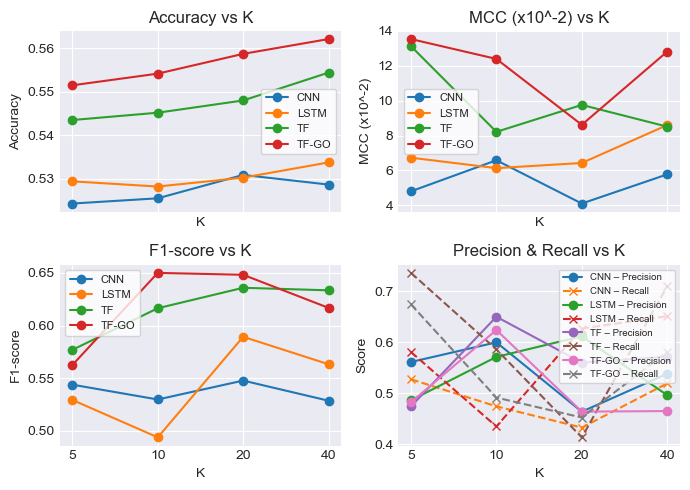

In [106]:
df["K"] = df["model"].str.extract(r"N(\d+)").astype(int)
df["base_model"] = df["model"].str.replace(r"_Daily_SP500_N\d+", "", regex=True)
test_df = df[df["split"] == "test"].copy()

k_vals = sorted(test_df["K"].unique())       
k_pos  = {k: i for i, k in enumerate(k_vals)}

plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(2, 2, figsize=(7, 5), sharex=True)
metrics = [
    ("acc", "Accuracy", axes[0, 0]),
    ("mcc", "MCC (x10^-2)", axes[0, 1]),
    ("f1",  "F1-score",    axes[1, 0]),
]

for metric, ylabel, ax in metrics:
    for name, grp in test_df.groupby("base_model"):
        grp = grp.sort_values("K")
        y = grp[metric] * 100 if metric == "mcc" else grp[metric] 
        ax.plot(grp["K"].map(k_pos), y, marker="o", label=name)
    ax.set_title(f"{ylabel} vs K")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("K")
    ax.set_xticks(range(len(k_vals)))
    ax.set_xticklabels(k_vals)
    ax.legend(loc="best", fontsize=8, frameon=True, facecolor="white", framealpha=0.8)

ax_pr = axes[1, 1]
for name, grp in test_df.groupby("base_model"):
    grp = grp.sort_values("K")
    ax_pr.plot(grp["K"].map(k_pos), grp["precision"], marker="o", label=f"{name} – Precision")
    ax_pr.plot(grp["K"].map(k_pos), grp["recall"],    marker="x", linestyle="--", label=f"{name} – Recall")
ax_pr.set_title("Precision & Recall vs K")
ax_pr.set_ylabel("Score")
ax_pr.set_xlabel("K")
ax_pr.set_xticks(range(len(k_vals)))
ax_pr.set_xticklabels(k_vals)
ax_pr.legend(loc="best", fontsize=7, frameon=True, facecolor="white", framealpha=0.8)

fig.tight_layout()
plt.show()

In [224]:
N = 40
d_model = 4**3
data.set_window(N)
Xtrain, ytrain, Xval, yval, Xtest, ytest = data.get_splits(tensor=True)
F = Xtrain.shape[2]
mg_daily = MG_Daily(N, F, d_model=d_model, pdrop=0.1)
mg_daily.apply(_init_weights)
print_num_params(mg_daily)

print("/n")
print(f"Nombre de stocks retenus: {len(data.raw.groupby(level=0))}")
print(f"Shape train: {Xtrain.shape}")
print(f"Shape val: {Xval.shape}")
print(f"Shape test: {Xtest.shape}")

trainer2 = BinaryTrainer(model=mg_daily,
                        X_train=Xtrain,
                        y_train=ytrain,
                        X_val=Xval,
                        y_val=yval,
                        batch_size=2**7,
                        num_epochs=5,
                        lr=3e-5,
                        name = f"TF_Daily_SP500_N{N}")

model2 = trainer2.model


[!] CRWD ignoré (< 41 lignes)
[!] CTVA ignoré (< 41 lignes)
[!] UBER ignoré (< 41 lignes)
Total parameters: 152,619
Trainable parameters: 152,619
/n
Nombre de stocks retenus: 488
Shape train: torch.Size([637241, 40, 5])
Shape val: torch.Size([79798, 40, 5])
Shape test: torch.Size([79333, 40, 5])


/Users/alexandre/ml_for_finance/src/trainer.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.ckpt_path, map_location=self.device)


/Users/alexandre/ml_for_finance/src/data.py:79: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  if df.empty:


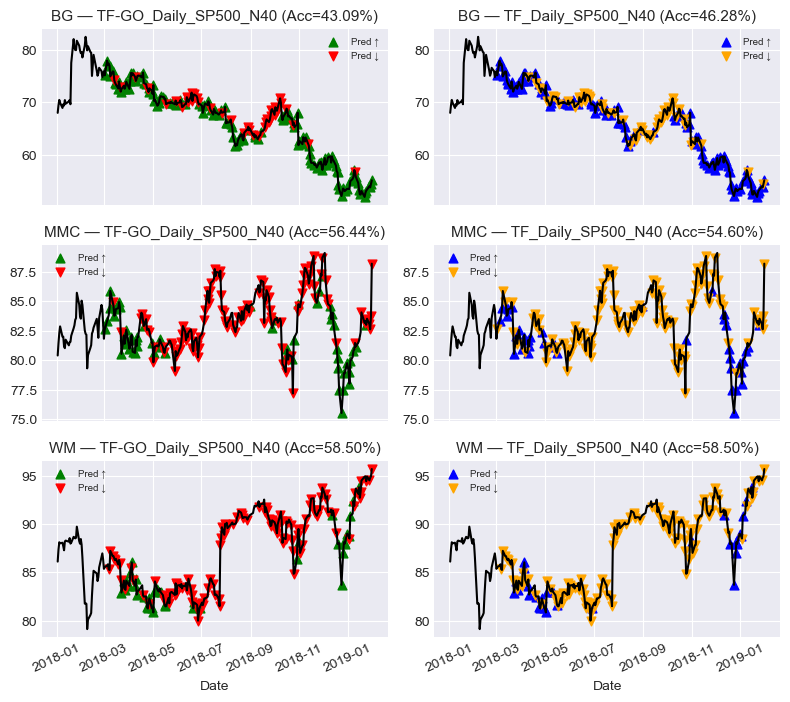

In [248]:
tickers = data.tickers
tickers_covid = random.sample(tickers, 3)

data_covid = MarketDataset(tickers=tickers_covid, start='2018-01-01', end='2019-02-01', window_N=40)
X_all, y_all, ts_all, tk_all = data_covid.get_dataset()
X_tensor = torch.from_numpy(X_all).float()
BATCH = 512

def predict_model(model, X_tensor):
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), BATCH):
            out = model(X_tensor[i:i+BATCH])
            if out.ndim == 2 and out.size(1) == 2:
                pred = torch.argmax(out, dim=1)
            else:
                pred = (out.squeeze(-1) > 0).long()
            y_pred_list.append(pred)
    return torch.cat(y_pred_list).cpu().numpy()

model1 = trainer.model
model2 = trainer2.model

y_pred1 = predict_model(model1, X_tensor)
y_pred2 = predict_model(model2, X_tensor)
y_true = y_all

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(len(tickers_covid), 2, figsize=(8, 2.5 * len(tickers_covid)), sharex=True)

for i, tkr in enumerate(tickers_covid):
    price = data_covid.raw.loc[(tkr,), "Close"]

    ax1 = axes[i, 0]
    mask = tk_all == tkr
    ts_pred = ts_all[mask]
    preds1 = y_pred1[mask]

    ax1.plot(price.index, price.values, color="black")
    ax1.scatter(ts_pred[preds1==1], price.reindex(ts_pred[preds1==1]).values, marker="^", s=40, color="green", label="Pred ↑")
    ax1.scatter(ts_pred[preds1==0], price.reindex(ts_pred[preds1==0]).values, marker="v", s=40, color="red", label="Pred ↓")
    acc1 = (preds1 == y_true[mask]).mean() * 100
    ax1.set_title(f"{tkr} — {trainer.name} (Acc={acc1:.2f}%)", fontsize=11)

    ax1.legend(loc="best", fontsize=7, framealpha=0.8)
    ax1.grid(True)

    ax2 = axes[i, 1]
    preds2 = y_pred2[mask]
    ax2.plot(price.index, price.values, color="black")
    ax2.scatter(ts_pred[preds2==1], price.reindex(ts_pred[preds2==1]).values, marker="^", s=40, color="blue", label="Pred ↑")
    ax2.scatter(ts_pred[preds2==0], price.reindex(ts_pred[preds2==0]).values, marker="v", s=40, color="orange", label="Pred ↓")
    acc2 = (preds2 == y_true[mask]).mean() * 100
    ax2.set_title(f"{tkr} — {trainer2.name} (Acc={acc2:.2f}%)", fontsize=11)
    ax2.legend(loc="best", fontsize=7, framealpha=0.8)
    ax2.grid(True)

for ax in axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(25)

axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Comment ces modèles performent pendant les crises?

L'intuition est que la période choisie par les auteurs ne contient pas forcément de mouvements aggressifs sur les actifs, et qu'en période de crise ils performeraient beaucoup moins bien.

/Users/alexandre/ml_for_finance/src/data.py:79: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  if df.empty:


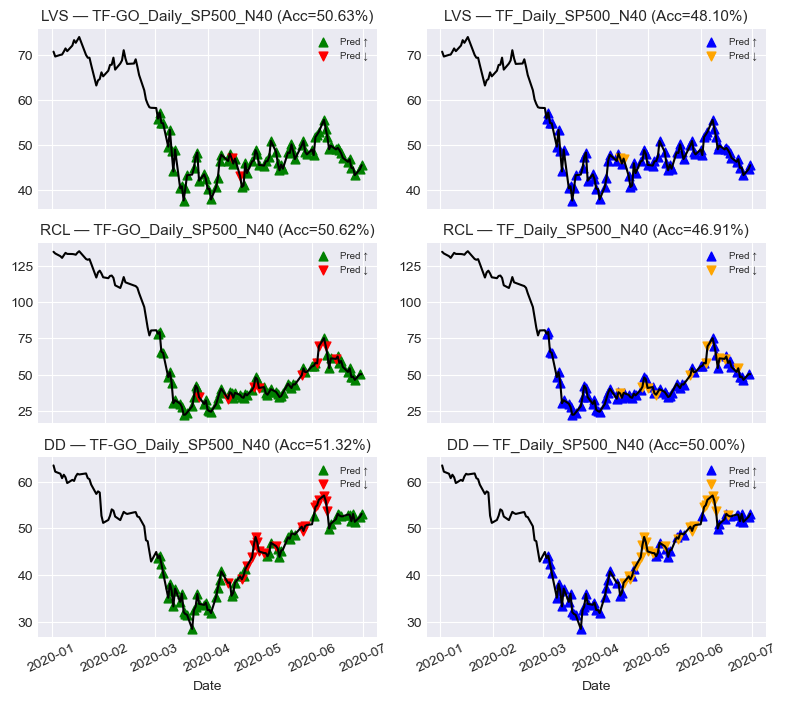

In [223]:
tickers = data.tickers
tickers_covid = random.sample(tickers, 3)

data_covid = MarketDataset(tickers=tickers_covid, start='2020-01-01', end='2020-07-01', window_N=40)
X_all, y_all, ts_all, tk_all = data_covid.get_dataset()
X_tensor = torch.from_numpy(X_all).float()
BATCH = 512

def predict_model(model, X_tensor):
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), BATCH):
            out = model(X_tensor[i:i+BATCH])
            if out.ndim == 2 and out.size(1) == 2:
                pred = torch.argmax(out, dim=1)
            else:
                pred = (out.squeeze(-1) > 0).long()
            y_pred_list.append(pred)
    return torch.cat(y_pred_list).cpu().numpy()

model1 = trainer.model
model2 = trainer2.model

y_pred1 = predict_model(model1, X_tensor)
y_pred2 = predict_model(model2, X_tensor)
y_true = y_all

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(len(tickers_covid), 2, figsize=(8, 2.5 * len(tickers_covid)), sharex=True)

for i, tkr in enumerate(tickers_covid):
    price = data_covid.raw.loc[(tkr,), "Close"]

    ax1 = axes[i, 0]
    mask = tk_all == tkr
    ts_pred = ts_all[mask]
    preds1 = y_pred1[mask]

    ax1.plot(price.index, price.values, color="black")
    ax1.scatter(ts_pred[preds1==1], price.reindex(ts_pred[preds1==1]).values, marker="^", s=40, color="green", label="Pred ↑")
    ax1.scatter(ts_pred[preds1==0], price.reindex(ts_pred[preds1==0]).values, marker="v", s=40, color="red", label="Pred ↓")
    acc1 = (preds1 == y_true[mask]).mean() * 100
    ax1.set_title(f"{tkr} — {trainer.name} (Acc={acc1:.2f}%)", fontsize=11)

    ax1.legend(loc="best", fontsize=7, framealpha=0.8)
    ax1.grid(True)

    ax2 = axes[i, 1]
    preds2 = y_pred2[mask]
    ax2.plot(price.index, price.values, color="black")
    ax2.scatter(ts_pred[preds2==1], price.reindex(ts_pred[preds2==1]).values, marker="^", s=40, color="blue", label="Pred ↑")
    ax2.scatter(ts_pred[preds2==0], price.reindex(ts_pred[preds2==0]).values, marker="v", s=40, color="orange", label="Pred ↓")
    acc2 = (preds2 == y_true[mask]).mean() * 100
    ax2.set_title(f"{tkr} — {trainer2.name} (Acc={acc2:.2f}%)", fontsize=11)
    ax2.legend(loc="best", fontsize=7, framealpha=0.8)
    ax2.grid(True)

for ax in axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(25)

axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
